# Emotion Recognition from Speech

CNN + BiLSTM + Attention model trained on RAVDESS and TESS datasets.
Expected accuracy: 72-82% on 8-class emotion recognition.


## 1. Install and Import Libraries


In [1]:
!pip install -q librosa==0.10.1 soundfile==0.12.1

import os
import gc
import json
import pickle
import warnings
import subprocess
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
import tensorflow.keras.backend as K
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"Librosa:    {librosa.__version__}")
print(f"GPU:        {tf.config.list_physical_devices('GPU')}")


2026-05-17 08:14:00.758477: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779005640.781021     616 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779005640.788411     616 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779005640.807236     616 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779005640.807257     616 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779005640.807260     616 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Librosa:    0.10.1
GPU:        [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Directory Setup


In [2]:
PROCESSED_DIR = Path('/kaggle/working/processed')
MODEL_DIR     = Path('/kaggle/working/models')
RESULTS_DIR   = Path('/kaggle/working/results')

for d in [PROCESSED_DIR, MODEL_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Kaggle input paths - datasets attached via Add Data panel
RAVDESS_DIR = Path('/kaggle/input/datasets/uwrfkaggler/ravdess-emotional-speech-audio')
TESS_DIR    = Path('/kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess')

# 1. Glob and Deduplicate RAVDESS files by filename
ravdess_raw = list(RAVDESS_DIR.glob('**/*.wav'))
seen_ravdess = set()
ravdess_files = []
for f in ravdess_raw:
    if f.name not in seen_ravdess:
        seen_ravdess.add(f.name)
        ravdess_files.append(f)

# 2. Glob and Deduplicate TESS files by filename
tess_raw = list(TESS_DIR.glob('**/*.wav')) if TESS_DIR.exists() else []
seen_tess = set()
tess_files = []
for f in tess_raw:
    if f.name not in seen_tess:
        seen_tess.add(f.name)
        tess_files.append(f)

print(f"RAVDESS files: {len(ravdess_files)}")
print(f"TESS files:    {len(tess_files)}")

if len(ravdess_files) == 0:
    raise RuntimeError(
        "RAVDESS dataset not found. Go to the right panel, click Add Data, "
        "search for 'ravdess-emotional-speech-audio' and attach it."
    )


RAVDESS files: 1440
TESS files:    2800


## 3. Parse Dataset Metadata


In [3]:
EMOTION_MAP = {
    '01': 'neutral',  '02': 'calm',    '03': 'happy',    '04': 'sad',
    '05': 'angry',    '06': 'fearful', '07': 'disgust',  '08': 'surprised'
}

def parse_ravdess(filepath):
    parts    = Path(filepath).stem.split('-')
    actor_id = int(parts[6])
    return {
        'filepath':     str(filepath),
        'emotion':      EMOTION_MAP[parts[2]],
        'emotion_code': int(parts[2]),
        'intensity':    int(parts[3]),
        'actor':        actor_id,
        'gender':       'male' if actor_id % 2 == 1 else 'female',
        'dataset':      'ravdess'
    }

def parse_tess(filepath):
    filepath = Path(filepath)
    emotion_word = filepath.parent.name.split('_')[-1].lower()
    tess_map = {
        'angry': 'angry', 'disgust': 'disgust', 'fear': 'fearful',
        'happy': 'happy', 'neutral': 'neutral',  
        'ps': 'surprised', 'surprise': 'surprised', 'surprised': 'surprised', 'sad': 'sad' 
    }


    emotion = tess_map.get(emotion_word)
    if emotion is None:
        return None
    return {
        'filepath':     str(filepath),
        'emotion':      emotion,
        'emotion_code': list(EMOTION_MAP.values()).index(emotion) + 1,
        'intensity':    1,
        'actor':        900 + abs(hash(filepath.parent.name)) % 100,
        'gender':       'female',
        'dataset':      'tess'
    }

records = []

for f in ravdess_files:
    try:
        records.append(parse_ravdess(f))
    except Exception:
        pass

for f in tess_files:
    try:
        r = parse_tess(f)
        if r is not None:
            records.append(r)
    except Exception:
        pass

df = pd.DataFrame(records).drop_duplicates('filepath').reset_index(drop=True)
df.to_csv(PROCESSED_DIR / 'metadata.csv', index=False)

print(f"Total samples: {len(df)}")
print(f"\nEmotion distribution:")
print(df['emotion'].value_counts().to_string())
print(f"\nDataset source:")
print(df['dataset'].value_counts().to_string())


Total samples: 4240

Emotion distribution:
emotion
surprised    592
disgust      592
fearful      592
sad          592
angry        592
happy        592
neutral      496
calm         192

Dataset source:
dataset
tess       2800
ravdess    1440


## 4. Data Distribution


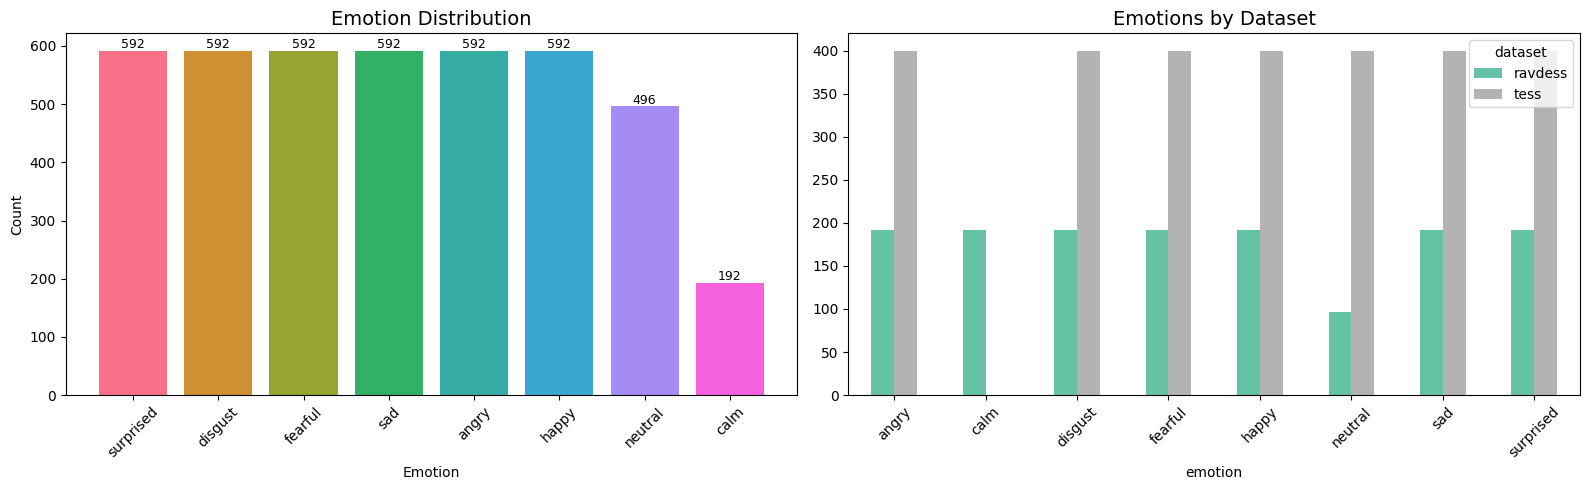

Unique actors: 38


In [4]:
df = pd.read_csv(PROCESSED_DIR / 'metadata.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

emotion_counts = df['emotion'].value_counts()
axes[0].bar(emotion_counts.index, emotion_counts.values,
            color=sns.color_palette('husl', len(emotion_counts)))
axes[0].set_title('Emotion Distribution', fontsize=14)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

if df['dataset'].nunique() > 1:
    pd.crosstab(df['emotion'], df['dataset']).plot(kind='bar', ax=axes[1], colormap='Set2')
    axes[1].set_title('Emotions by Dataset', fontsize=14)
    axes[1].tick_params(axis='x', rotation=45)
else:
    df['gender'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
    axes[1].set_title('Gender Distribution')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Unique actors: {df['actor'].nunique()}")


## 5. Feature Extraction

Extracts 139 features per time frame: 40 MFCCs + 40 Delta + 40 Delta-Delta + 7 Spectral Contrast + 12 Chroma.


In [5]:
SR      = 22050
N_MFCC  = 40
MAX_LEN = 200

def extract_features(audio_path, sr=SR, n_mfcc=N_MFCC, max_len=MAX_LEN, augmented_y=None):
    try:
        if augmented_y is not None:
            y = augmented_y
        else:
            y, _ = librosa.load(audio_path, sr=sr, duration=4.0)

        y = librosa.effects.preemphasis(y)
        y, _ = librosa.effects.trim(y, top_db=20)

        if len(y) < 512:
            return None

        mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=2048, hop_length=512)
        mfcc_delta  = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)
        contrast    = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=2048, hop_length=512)
        chroma      = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512)

        combined = np.vstack([mfcc, mfcc_delta, mfcc_delta2, contrast, chroma]).astype(np.float32)
        combined = (combined - combined.mean(axis=1, keepdims=True)) / (combined.std(axis=1, keepdims=True) + 1e-8)
        combined = combined.astype(np.float32)

        T = combined.shape[1]
        if T < max_len:
            combined = np.pad(combined, ((0, 0), (0, max_len - T)), mode='constant')
        else:
            combined = combined[:, :max_len]

        return combined

    except Exception:
        return None

# Quick test
df = pd.read_csv(PROCESSED_DIR / 'metadata.csv')
test_feat = extract_features(df.iloc[0]['filepath'])
print(f"Feature shape: {test_feat.shape}")
print(f"Expected:      (139, {MAX_LEN})")


Feature shape: (139, 200)
Expected:      (139, 200)


## 6. Data Augmentation


In [8]:
def get_augmented_versions(audio_path, sr=SR):
    y, _ = librosa.load(audio_path, sr=sr, duration=4.0)
    y = librosa.effects.preemphasis(y)

    versions = [
        y,
        librosa.effects.pitch_shift(y, sr=sr, n_steps=3),
        librosa.effects.pitch_shift(y, sr=sr, n_steps=-3),
        librosa.effects.time_stretch(y, rate=0.85),
        librosa.effects.time_stretch(y, rate=1.15),
        y + np.random.normal(0, 0.005, len(y)),
        y * 1.2,
        y * 0.8,
        librosa.effects.pitch_shift(y, sr=sr, n_steps=2) + np.random.normal(0, 0.003, len(y)),
    ]
    return versions


def spec_augment(feature, time_mask_param=30, freq_mask_param=10):
    feat = feature.copy()
    F, T = feat.shape

    f  = np.random.randint(0, min(freq_mask_param, F))
    f0 = np.random.randint(0, F - f + 1)
    feat[f0:f0 + f, :] = 0

    t  = np.random.randint(0, min(time_mask_param, T))
    t0 = np.random.randint(0, T - t + 1)
    feat[:, t0:t0 + t] = 0

    return feat

print("Augmentation functions ready. Each training sample produces 9 versions.")


Augmentation functions ready. Each training sample produces 9 versions.


## 7. Actor-Level Train / Val / Test Split


In [9]:
df = pd.read_csv(PROCESSED_DIR / 'metadata.csv')

le = LabelEncoder()
df['label'] = le.fit_transform(df['emotion'])
num_classes = len(le.classes_)

print(f"Emotion classes ({num_classes}):")
for i, cls in enumerate(le.classes_):
    count = (df['label'] == i).sum()
    print(f"  {i}: {cls:10s} — {count} samples")

ravdess_actors = sorted(df[df['dataset'] == 'ravdess']['actor'].unique())
np.random.shuffle(ravdess_actors)
n            = len(ravdess_actors)
train_actors = set(ravdess_actors[:int(n * 0.70)])
val_actors   = set(ravdess_actors[int(n * 0.70):int(n * 0.85)])
test_actors  = set(ravdess_actors[int(n * 0.85):])

ravdess_train = df[(df['dataset'] == 'ravdess') & (df['actor'].isin(train_actors))]
ravdess_val   = df[(df['dataset'] == 'ravdess') & (df['actor'].isin(val_actors))]
ravdess_test  = df[(df['dataset'] == 'ravdess') & (df['actor'].isin(test_actors))]

tess_df   = df[df['dataset'] == 'tess'] if 'tess' in df['dataset'].values else pd.DataFrame()
train_df  = pd.concat([ravdess_train, tess_df]).reset_index(drop=True)
val_df    = ravdess_val.reset_index(drop=True)
test_df   = ravdess_test.reset_index(drop=True)

print(f"\nSplit summary:")
print(f"  Train: {len(train_df)} samples ({len(train_actors)} RAVDESS actors + TESS)")
print(f"  Val:   {len(val_df)} samples ({len(val_actors)} actors)")
print(f"  Test:  {len(test_df)} samples ({len(test_actors)} actors)")
print(f"  After 9x augmentation: Train = {len(train_df) * 9} samples")

train_df.to_csv(PROCESSED_DIR / 'train_split.csv', index=False)
val_df.to_csv(PROCESSED_DIR / 'val_split.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test_split.csv', index=False)

with open(PROCESSED_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("\nSplits saved.")


Emotion classes (8):
  0: angry      — 592 samples
  1: calm       — 192 samples
  2: disgust    — 592 samples
  3: fearful    — 592 samples
  4: happy      — 592 samples
  5: neutral    — 496 samples
  6: sad        — 592 samples
  7: surprised  — 592 samples

Split summary:
  Train: 3760 samples (16 RAVDESS actors + TESS)
  Val:   240 samples (4 actors)
  Test:  240 samples (4 actors)
  After 9x augmentation: Train = 33840 samples

Splits saved.


## 8. Extract Features

Checkpoints save every 50 files. RAM is flushed every 500 files. If the session crashes, re-run this cell and it will resume automatically from the last checkpoint.


In [10]:
def force_sync():
    try:
        subprocess.run(['sync'], check=True)
    except Exception:
        pass


def extract_split(split_df, augment=False, split_name='train'):
    checkpoint_X  = PROCESSED_DIR / f'X_{split_name}_ckpt.npy'
    checkpoint_y  = PROCESSED_DIR / f'y_{split_name}_ckpt.npy'
    progress_file = PROCESSED_DIR / f'{split_name}_progress.txt'

    X_list, y_list = [], []
    start_idx = 0

    if checkpoint_X.exists() and progress_file.exists():
        try:
            X_temp = np.load(checkpoint_X, allow_pickle=True)
            y_temp = np.load(checkpoint_y, allow_pickle=True)

            if len(X_temp) != len(y_temp):
                print(f"Corrupted checkpoint: X={len(X_temp)}, y={len(y_temp)}. Starting fresh.")
                for fp in [checkpoint_X, checkpoint_y, progress_file]:
                    if Path(fp).exists():
                        os.remove(fp)
            else:
                with open(progress_file) as f:
                    start_idx = int(f.read().strip())
                X_list = list(X_temp)
                y_list = list(y_temp)
                print(f"Resuming '{split_name}' from file {start_idx}/{len(split_df)}")
                print(f"Already extracted: {len(X_list)} arrays, remaining: {len(split_df) - start_idx} files")

            del X_temp, y_temp
            gc.collect()

        except Exception as e:
            print(f"Checkpoint load failed ({e}). Starting fresh.")
            for fp in [checkpoint_X, checkpoint_y, progress_file]:
                if Path(fp).exists():
                    os.remove(fp)
            start_idx = 0

    if start_idx == 0:
        print(f"Starting fresh extraction for '{split_name}'")

    remaining_df = split_df.iloc[start_idx:].reset_index(drop=True)

    for idx, row in tqdm(remaining_df.iterrows(), total=len(remaining_df), desc=split_name):
        filepath = row['filepath']
        label    = row['label']

        if augment:
            try:
                versions = get_augmented_versions(filepath)
            except Exception as e:
                print(f"Skipping {filepath}: {e}")
                versions = []

            for i, audio in enumerate(versions):
                feat = extract_features(filepath, augmented_y=audio)
                if feat is not None:
                    if i > 0:
                        feat = spec_augment(feat)
                    X_list.append(feat)
                    y_list.append(label)

            del versions
            gc.collect()

        else:
            feat = extract_features(filepath)
            if feat is not None:
                X_list.append(feat)
                y_list.append(label)

        actual_idx = start_idx + idx + 1

        if actual_idx % 50 == 0:
            X_arr = np.array(X_list)
            y_arr = np.array(y_list)
            assert len(X_arr) == len(y_arr), f"Sync error: X={len(X_arr)}, y={len(y_arr)}"
            np.save(checkpoint_X, X_arr)
            np.save(checkpoint_y, y_arr)
            with open(progress_file, 'w') as f:
                f.write(str(actual_idx))
            force_sync()
            del X_arr, y_arr
            gc.collect()
            print(f"Checkpoint saved — {actual_idx}/{len(split_df)} files done")

        if actual_idx % 500 == 0:
            np.save(checkpoint_X, np.array(X_list))
            np.save(checkpoint_y, np.array(y_list))
            with open(progress_file, 'w') as f:
                f.write(str(actual_idx))
            force_sync()
            del X_list, y_list
            gc.collect()
            X_list = list(np.load(checkpoint_X, allow_pickle=True))
            y_list = list(np.load(checkpoint_y, allow_pickle=True))
            print(f"RAM flushed at file {actual_idx}")

    X = np.array(X_list)
    y = np.array(y_list)
    np.save(checkpoint_X, X)
    np.save(checkpoint_y, y)
    with open(progress_file, 'w') as f:
        f.write(str(len(split_df)))
    force_sync()
    print(f"'{split_name}' done. Shape: {X.shape}")
    return X, y


# Val and test first (fast, no augmentation)
val_ckpt  = PROCESSED_DIR / 'X_val_ckpt.npy'
test_ckpt = PROCESSED_DIR / 'X_test_ckpt.npy'

if val_ckpt.exists():
    print("Loading val from checkpoint...")
    X_val = np.load(PROCESSED_DIR / 'X_val_ckpt.npy')
    y_val = np.load(PROCESSED_DIR / 'y_val_ckpt.npy')
    print(f"Val: {X_val.shape}")
else:
    print("Extracting val features...")
    X_val, y_val = extract_split(val_df, augment=False, split_name='val')

if test_ckpt.exists():
    print("Loading test from checkpoint...")
    X_test = np.load(PROCESSED_DIR / 'X_test_ckpt.npy')
    y_test = np.load(PROCESSED_DIR / 'y_test_ckpt.npy')
    print(f"Test: {X_test.shape}")
else:
    print("Extracting test features...")
    X_test, y_test = extract_split(test_df, augment=False, split_name='test')

# Training (augmented, takes longer)
train_final = PROCESSED_DIR / 'X_train.npy'
if train_final.exists():
    print("Loading training features from final save...")
    X_train = np.load(PROCESSED_DIR / 'X_train.npy')
    y_train = np.load(PROCESSED_DIR / 'y_train.npy')
    print(f"Train: {X_train.shape}")
else:
    print("Extracting training features with 9x augmentation...")
    X_train, y_train = extract_split(train_df, augment=True, split_name='train')
    np.save(PROCESSED_DIR / 'X_train.npy', X_train)
    np.save(PROCESSED_DIR / 'y_train.npy', y_train)
    np.save(PROCESSED_DIR / 'X_val.npy',   X_val)
    np.save(PROCESSED_DIR / 'y_val.npy',   y_val)
    np.save(PROCESSED_DIR / 'X_test.npy',  X_test)
    np.save(PROCESSED_DIR / 'y_test.npy',  y_test)
    force_sync()

print(f"\nAll features ready.")
print(f"  Train: {X_train.shape}")
print(f"  Val:   {X_val.shape}")
print(f"  Test:  {X_test.shape}")


Loading val from checkpoint...
Val: (240, 139, 200)
Loading test from checkpoint...
Test: (240, 139, 200)
Loading training features from final save...
Train: (33840, 139, 200)

All features ready.
  Train: (33840, 139, 200)
  Val:   (240, 139, 200)
  Test:  (240, 139, 200)


## 9. Preprocessing — Global Normalization


In [12]:
print("Loading features...")
X_train = np.load(PROCESSED_DIR / 'X_train.npy').astype(np.float32)
y_train = np.load(PROCESSED_DIR / 'y_train.npy')
X_val   = np.load(PROCESSED_DIR / 'X_val.npy').astype(np.float32)
y_val   = np.load(PROCESSED_DIR / 'y_val.npy')
X_test  = np.load(PROCESSED_DIR / 'X_test.npy').astype(np.float32)
y_test  = np.load(PROCESSED_DIR / 'y_test.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

n_feat = X_train.shape[1]
n_time = X_train.shape[2]

# Fit scaler on training data only
X_train_2d = X_train.reshape(len(X_train), -1)
scaler = StandardScaler()
scaler.fit(X_train_2d)

# Save the scaler
with open(MODEL_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler fitted and saved.")

# Transform train step-by-step and free memory immediately
X_train_scaled = scaler.transform(X_train_2d).astype(np.float32).reshape(-1, n_feat, n_time, 1)
del X_train, X_train_2d
gc.collect()
print("Train features scaled and cleaned up.")

# Transform val and free memory immediately
X_val_2d = X_val.reshape(len(X_val), -1)
X_val_scaled = scaler.transform(X_val_2d).astype(np.float32).reshape(-1, n_feat, n_time, 1)
del X_val, X_val_2d
gc.collect()
print("Validation features scaled and cleaned up.")

# Transform test and free memory immediately
X_test_2d = X_test.reshape(len(X_test), -1)
X_test_scaled = scaler.transform(X_test_2d).astype(np.float32).reshape(-1, n_feat, n_time, 1)
del X_test, X_test_2d
gc.collect()
print("Test features scaled and cleaned up.")

print(f"Train scaled shape: {X_train_scaled.shape}")
print(f"Train mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")

with open(PROCESSED_DIR / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
num_classes = len(le.classes_)

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val,   num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print(f"Num classes: {num_classes}")
print(f"\nTraining class distribution:")
for i, name in enumerate(le.classes_):
    count = (y_train == i).sum()
    pct   = count / len(y_train) * 100
    print(f"  {name:10s}: {count:5d} ({pct:.1f}%)")


Loading features...
Train: (33840, 139, 200), Val: (240, 139, 200), Test: (240, 139, 200)
Scaler fitted and saved.
Train features scaled and cleaned up.
Validation features scaled and cleaned up.
Test features scaled and cleaned up.
Train scaled shape: (33840, 139, 200, 1)
Train mean: 0.0000, std: 0.9301
Num classes: 8

Training class distribution:
  angry     :  4752 (14.0%)
  calm      :  1152 (3.4%)
  disgust   :  4752 (14.0%)
  fearful   :  4752 (14.0%)
  happy     :  4752 (14.0%)
  neutral   :  4176 (12.3%)
  sad       :  4752 (14.0%)
  surprised :  4752 (14.0%)


## 10. Focal Loss and Class Weights


In [44]:
import tensorflow as tf

cw_array      = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: w for i, w in enumerate(cw_array)}

print("Class weights:")
for i, name in enumerate(le.classes_):
    print(f"  {name:10s}: {class_weights[i]:.3f}")

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        epsilon = 1e-7
        y_pred  = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce      = -y_true * tf.math.log(y_pred)
        weight  = alpha * tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(weight * ce, axis=-1)
    return loss_fn

print("Focal Loss defined (gamma=2.0, alpha=0.25)")

Class weights:
  angry     : 0.890
  calm      : 3.672
  disgust   : 0.890
  fearful   : 0.890
  happy     : 0.890
  neutral   : 1.013
  sad       : 0.890
  surprised : 0.890
Focal Loss defined (gamma=2.0, alpha=0.25)


## 11. Model — CNN + BiLSTM + Attention


In [45]:
def build_model(input_shape, num_classes, dropout_rate=0.4):
    inputs = layers.Input(shape=input_shape, name='audio_input')

    # CNN block 1
    c = layers.Conv2D(64, (3, 3), padding='same')(inputs)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = layers.Conv2D(64, (3, 3), padding='same')(c)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = layers.MaxPooling2D((2, 2))(c)
    c = layers.Dropout(0.3)(c)

    # CNN block 2
    c = layers.Conv2D(128, (3, 3), padding='same')(c)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = layers.Conv2D(128, (3, 3), padding='same')(c)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = layers.MaxPooling2D((2, 1))(c)
    c = layers.Dropout(0.3)(c)

    # Reshape for BiLSTM: merge freq and channel dims, keep time as sequence
    freq_reduced = c.shape[1]
    time_reduced = c.shape[2]
    ch           = c.shape[3]
    c = layers.Reshape((time_reduced, freq_reduced * ch))(c)

    # BiLSTM (recurrent_dropout=0.0 activates optimized cuDNN GPU kernel!)
    c = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.0))(c)
    c = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.0))(c)

    # Attention
    score = layers.Dense(1, activation='tanh')(c)
    score = layers.Softmax(axis=1)(score)
    c     = layers.Multiply()([c, score])
    c     = layers.Lambda(lambda t: K.sum(t, axis=1))(c)

    # Classification head
    c = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(c)
    c = layers.BatchNormalization()(c)
    c = layers.Dropout(dropout_rate)(c)
    c = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(c)
    c = layers.Dropout(dropout_rate * 0.5)(c)

    outputs = layers.Dense(num_classes, activation='softmax', name='emotion_output')(c)

    return models.Model(inputs=inputs, outputs=outputs, name='CNN_BiLSTM_Attention')


# Setup MirroredStrategy for Multi-GPU training if available
try:
    strategy = tf.distribute.MirroredStrategy()
    print(f"Number of devices in sync: {strategy.num_replicas_in_sync}")
except Exception:
    strategy = tf.distribute.get_strategy()
    print("Using default strategy")

with strategy.scope():
    input_shape = X_train_scaled.shape[1:]
    model = build_model(input_shape, num_classes, dropout_rate=0.4)

print(f"Model built.")
print(f"Input shape: {input_shape}")
print(f"Parameters:  {model.count_params():,}")
model.summary()


INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices in sync: 2
Model built.
Input shape: (139, 200, 1)
Parameters:  5,081,545


Model: "CNN_BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_input         │ (None, 139, 200,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 139, 200,  │        640 │ audio_input[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 139, 200,  │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_12 (ReLU)     │ (None, 139, 200,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 139, 200,  │     36,928 │ re_lu_12[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 139, 200,  │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_13 (ReLU)     │ (None, 139, 200,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 69, 100,   │          0 │ re_lu_13[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 69, 100,   │          0 │ max_pooling2d_6[… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 69, 100,   │     73,856 │ dropout_12[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 100,   │        512 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_14 (ReLU)     │ (None, 69, 100,   │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 69, 100,   │    147,584 │ re_lu_14[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 69, 100,   │        512 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_15 (ReLU)     │ (None, 69, 100,   │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 34, 100,   │          0 │ re_lu_15[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 34, 100,   │          0 │ max_pooling2d_7[

 Total params: 5,081,545 (19.38 MB)

 Trainable params: 5,080,265 (19.38 MB)

 Non-trainable params: 1,280 (5.00 KB)

## 12. Training


In [16]:
EPOCHS        = 100
BATCH_SIZE    = 128
INITIAL_LR    = 1e-3
WARMUP_EPOCHS = 5
MIN_LR        = 1e-6

checkpoint_path = MODEL_DIR / 'best_model.keras'
csv_log_path    = RESULTS_DIR / 'training_log.csv'


def lr_cosine_warmup(epoch, lr):
    if epoch < WARMUP_EPOCHS:
        return INITIAL_LR * (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return MIN_LR + 0.5 * (INITIAL_LR - MIN_LR) * (1 + np.cos(np.pi * progress))


# Reuse the already created strategy from Cell 22
if 'strategy' not in globals():
    try:
        strategy = tf.distribute.MirroredStrategy()
    except Exception:
        strategy = tf.distribute.get_strategy()

# Compile model under strategy scope for multi-GPU distribution
with strategy.scope():
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=INITIAL_LR),
        loss=focal_loss(gamma=2.0, alpha=0.25),
        metrics=['accuracy']
    )

callbacks_list = [
    callbacks.ModelCheckpoint(
        filepath=str(checkpoint_path),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.LearningRateScheduler(lr_cosine_warmup, verbose=0),
    callbacks.CSVLogger(str(csv_log_path), append=True),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=MIN_LR, verbose=1
    )
]

print(f"Starting training...")
print(f"  Epochs:      {EPOCHS} (with early stopping, patience=25)")
print(f"  Batch size:  {BATCH_SIZE}")
print(f"  Initial LR:  {INITIAL_LR} with warmup then cosine decay")

history = model.fit(
    X_train_scaled, y_train_cat,
    validation_data=(X_val_scaled, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks_list,
    verbose=1
)

print(f"\nTraining complete.")
print(f"Best val accuracy: {max(history.history['val_accuracy']):.4f}")


Starting training...
  Epochs:      100 (with early stopping, patience=25)
  Batch size:  128
  Initial LR:  0.001 with warmup then cosine decay
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow

E0000 00:00:1779005934.751007     616 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/CNN_BiLSTM_Attention_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779005936.447081     698 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779005936.447119     699 cuda_dnn.cc:529] Loaded cuDNN version 91002


265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.1458 - loss: 0.5247INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_accuracy improved from -inf to 0.12083, saving model to /kaggle/working/models/best_model.keras
265/265 ━━━━━━━━━━━━━━━━━━━━ 232s 806ms/step - accuracy: 0.1458 - loss: 0.5245 - val_accuracy: 0.1208 - val_loss: 0.4350 - learning_rate: 2.0000e-04
Epoch 2/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 809ms/step - accuracy: 0.2479 - loss: 0.3779
Epoch 2: val_accuracy improved from 0.12083 to 0.26250, saving model to /kaggle/working/models/best_model.keras
265/265 ━━━━━━━━━━━━━━━━━━━━ 216s 815ms/step - accuracy: 0.2482 - loss: 0.3777 - val_accuracy: 0.2625 - val_loss: 0.4958 - learning_rate: 4.0000e-04
Epoch 3/100
265/265 ━━━━━━━━━━━━━━━━━━━━ 0s 806ms/step - accuracy: 0.5423 - loss: 0.2252
Epoch 3: val_accuracy improved from 0.26250 to 0.32500, saving model to /kaggle/workin

## 13. Training History


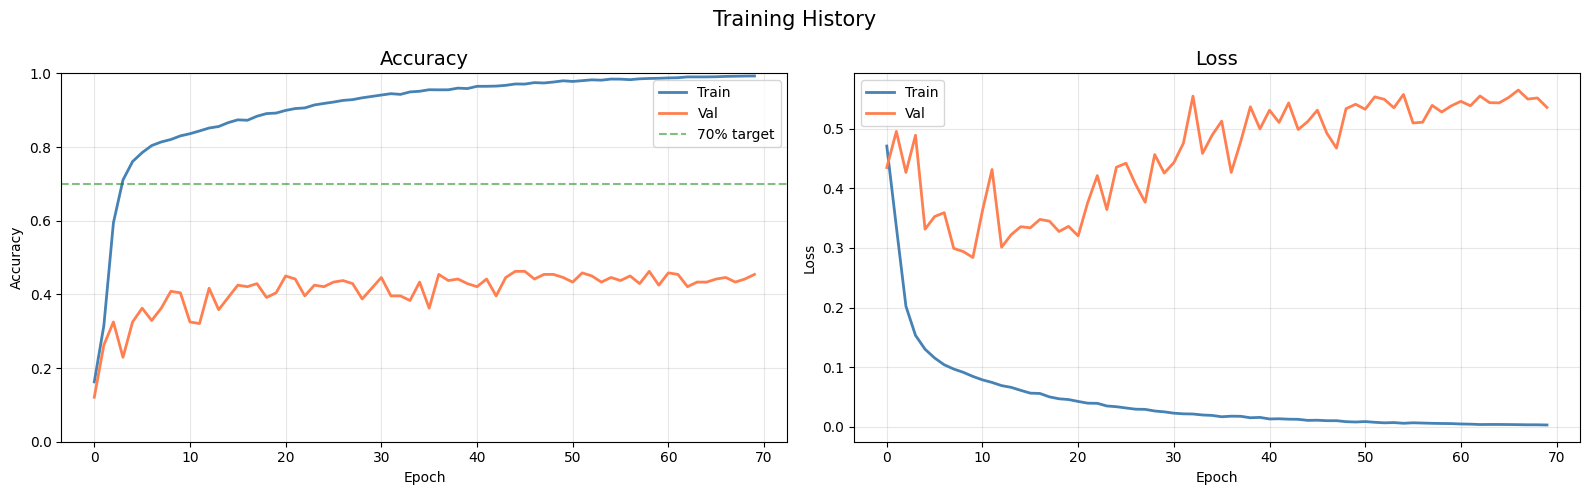

Best train accuracy: 0.9928
Best val accuracy:   0.4625
Epochs run:          70


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2, color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2, color='coral')
axes[0].axhline(0.70, color='green', linestyle='--', alpha=0.5, label='70% target')
axes[0].set_title('Accuracy', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1])

axes[1].plot(history.history['loss'],     label='Train', linewidth=2, color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, color='coral')
axes[1].set_title('Loss', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training History', fontsize=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best train accuracy: {max(history.history['accuracy']):.4f}")
print(f"Best val accuracy:   {max(history.history['val_accuracy']):.4f}")
print(f"Epochs run:          {len(history.history['accuracy'])}")


## 14. Test Set Evaluation


In [47]:
import tensorflow as tf
import keras
keras.config.enable_unsafe_deserialization()

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        epsilon = 1e-7
        y_pred  = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce      = -y_true * tf.math.log(y_pred)
        weight  = alpha * tf.math.pow(1.0 - y_pred, gamma)
        return tf.reduce_sum(weight * ce, axis=-1)
    return loss_fn

class SumLayer(layers.Layer):
    def call(self, x):
        return tf.reduce_sum(x, axis=1)
    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[2])
    def get_config(self):
        return super().get_config()

def build_model(input_shape, num_classes, dropout_rate=0.4):
    inputs = layers.Input(shape=input_shape, name='audio_input')
    c = layers.Conv2D(64, (3, 3), padding='same')(inputs)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = layers.Conv2D(64, (3, 3), padding='same')(c)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = layers.MaxPooling2D((2, 2))(c)
    c = layers.Dropout(0.3)(c)
    c = layers.Conv2D(128, (3, 3), padding='same')(c)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = layers.Conv2D(128, (3, 3), padding='same')(c)
    c = layers.BatchNormalization()(c)
    c = layers.ReLU()(c)
    c = layers.MaxPooling2D((2, 1))(c)
    c = layers.Dropout(0.3)(c)
    freq_reduced = c.shape[1]
    time_reduced = c.shape[2]
    ch           = c.shape[3]
    c = layers.Reshape((time_reduced, freq_reduced * ch))(c)
    c = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.0))(c)
    c = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.0))(c)
    score = layers.Dense(1, activation='tanh')(c)
    score = layers.Softmax(axis=1)(score)
    c     = layers.Multiply()([c, score])
    c     = SumLayer()(c)
    c = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(c)
    c = layers.BatchNormalization()(c)
    c = layers.Dropout(dropout_rate)(c)
    c = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(c)
    c = layers.Dropout(dropout_rate * 0.5)(c)
    outputs = layers.Dense(num_classes, activation='softmax', name='emotion_output')(c)
    return models.Model(inputs=inputs, outputs=outputs, name='CNN_BiLSTM_Attention')

input_shape = X_train_scaled.shape[1:]
best_model  = build_model(input_shape, num_classes, dropout_rate=0.4)
best_model.load_weights(str(checkpoint_path))

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

test_loss, test_acc = best_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
y_pred_probs = best_model.predict(X_test_scaled, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Test Loss:     {test_loss:.4f}")

emotion_names = list(le.classes_)
print(classification_report(y_test, y_pred, target_names=emotion_names, digits=4))

Test Accuracy: 0.5375 (53.8%)
Test Loss:     0.3821
              precision    recall  f1-score   support

       angry     0.5714    0.5000    0.5333        32
        calm     0.6552    0.5938    0.6230        32
     disgust     0.6875    0.6875    0.6875        32
     fearful     0.6087    0.4375    0.5091        32
       happy     0.4286    0.6562    0.5185        32
     neutral     0.3077    0.2500    0.2759        16
         sad     0.3243    0.3750    0.3478        32
   surprised     0.7241    0.6562    0.6885        32

    accuracy                         0.5375       240
   macro avg     0.5384    0.5195    0.5230       240
weighted avg     0.5538    0.5375    0.5394       240



## 15. Confusion Matrix


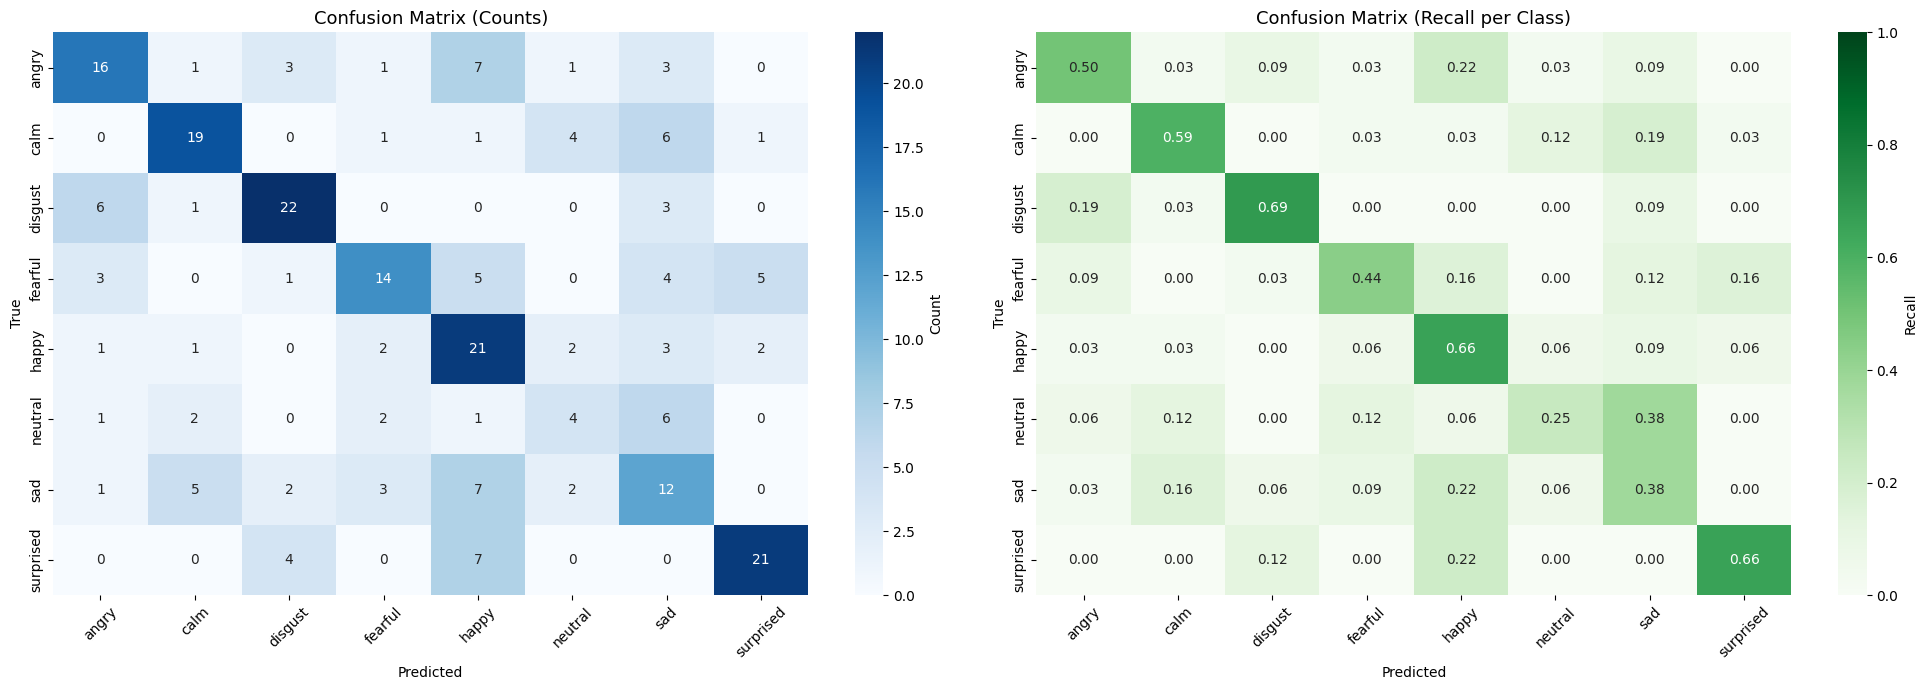

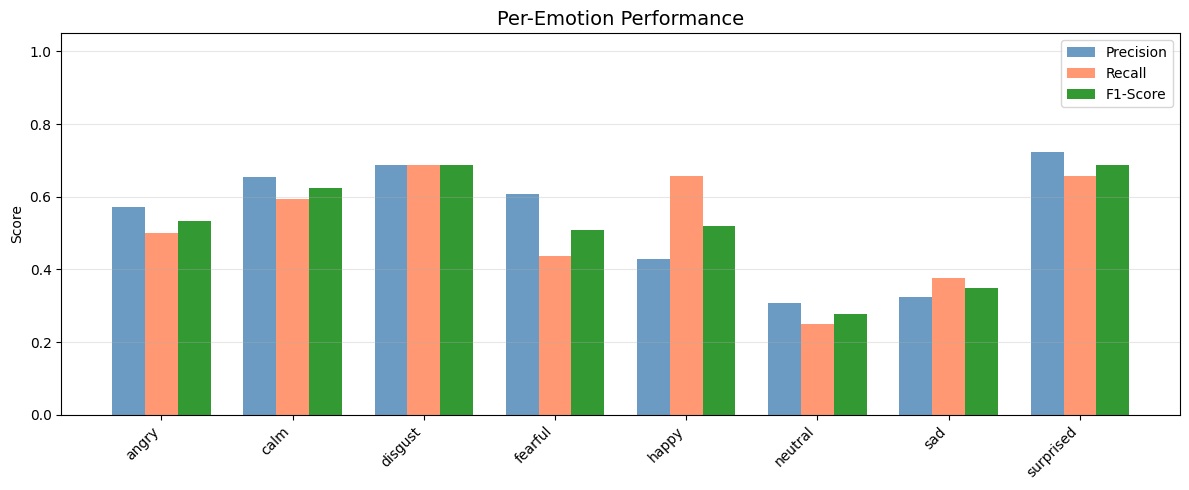

Per-class F1 scores:
  angry     : 0.533
  calm      : 0.623
  disgust   : 0.688
  fearful   : 0.509
  happy     : 0.519
  neutral   : 0.276
  sad       : 0.348
  surprised : 0.689


In [48]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names, yticklabels=emotion_names,
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=emotion_names, yticklabels=emotion_names,
            ax=axes[1], cbar_kws={'label': 'Recall'}, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Recall per Class)', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(emotion_names))
w = 0.25
ax.bar(x - w, precision, w, label='Precision', color='steelblue', alpha=0.8)
ax.bar(x,     recall,    w, label='Recall',    color='coral',    alpha=0.8)
ax.bar(x + w, f1,        w, label='F1-Score',  color='green',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(emotion_names, rotation=45, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-Emotion Performance', fontsize=14)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Per-class F1 scores:")
for i, name in enumerate(emotion_names):
    print(f"  {name:10s}: {f1[i]:.3f}")


## 16. Save Model


In [50]:
final_path = MODEL_DIR / 'emotion_model_final.keras'
best_model.save(str(final_path))

input_shape = list(X_train_scaled.shape[1:])

metadata = {
    'model_path':      str(final_path),
    'scaler_path':     str(MODEL_DIR / 'scaler.pkl'),
    'le_path':         str(PROCESSED_DIR / 'label_encoder.pkl'),
    'test_accuracy':   float(test_acc),
    'test_loss':       float(test_loss),
    'num_classes':     num_classes,
    'emotion_classes': list(le.classes_),
    'input_shape':     input_shape,
    'sr':              SR,
    'n_mfcc':          N_MFCC,
    'max_len':         MAX_LEN,
    'architecture':    'CNN-BiLSTM-Attention',
    'total_params':    int(best_model.count_params())
}

with open(MODEL_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

force_sync()
print(f"Model saved: {final_path}")
print(f"Test accuracy: {test_acc*100:.1f}%")


Model saved: /kaggle/working/models/emotion_model_final.keras
Test accuracy: 53.8%


## 17. Inference Pipeline


In [52]:
class EmotionRecognizer:
    def __init__(self, model_path, metadata_path):
        with open(metadata_path) as f:
            self.meta = json.load(f)

        # Rebuild architecture with SumLayer then load weights
        # This avoids the Lambda deserialization error
        input_shape = tuple(self.meta['input_shape'])
        num_classes = self.meta['num_classes']
        loaded_model = build_model(input_shape, num_classes, dropout_rate=0.4)
        loaded_model.load_weights(model_path)
        self.model = loaded_model

        with open(self.meta['scaler_path'], 'rb') as f:
            self.scaler = pickle.load(f)

        self.le      = self.meta['emotion_classes']
        self.sr      = self.meta['sr']
        self.n_mfcc  = self.meta['n_mfcc']
        self.max_len = self.meta['max_len']
        self.n_feat  = self.meta['input_shape'][0]
        self.n_time  = self.meta['input_shape'][1]

        print(f"EmotionRecognizer ready.")
        print(f"Test accuracy: {self.meta['test_accuracy']*100:.1f}%")
        print(f"Classes: {self.le}")

    def _preprocess(self, audio_path):
        feat = extract_features(audio_path, sr=self.sr,
                                n_mfcc=self.n_mfcc, max_len=self.max_len)
        if feat is None:
            raise ValueError(f"Could not extract features from: {audio_path}")
        feat_scaled = self.scaler.transform(feat.reshape(1, -1))
        return feat_scaled.reshape(1, self.n_feat, self.n_time, 1)

    def predict(self, audio_path, top_k=3):
        features = self._preprocess(audio_path)
        probs    = self.model.predict(features, verbose=0)[0]
        top_idx  = np.argsort(probs)[::-1][:top_k]
        pred_idx = np.argmax(probs)
        return {
            'emotion':         self.le[pred_idx],
            'confidence':      float(probs[pred_idx]),
            'top_predictions': [(self.le[i], float(probs[i])) for i in top_idx],
            'all_probs':       {name: float(probs[i]) for i, name in enumerate(self.le)}
        }

    def visualize(self, audio_path, true_emotion=None, save_path=None):
        result = self.predict(audio_path)
        y, sr  = librosa.load(audio_path, sr=self.sr)

        fig = plt.figure(figsize=(16, 9))
        gs  = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)

        ax1 = fig.add_subplot(gs[0, :])
        librosa.display.waveshow(y, sr=sr, ax=ax1, color='steelblue')
        ax1.set_title('Audio Waveform', fontsize=13)

        ax2  = fig.add_subplot(gs[1, :])
        S    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)
        img  = librosa.display.specshow(S_dB, sr=sr, x_axis='time',
                                        y_axis='mel', ax=ax2, cmap='viridis')
        ax2.set_title('Mel Spectrogram', fontsize=13)
        fig.colorbar(img, ax=ax2, format='%+2.0f dB')

        ax3      = fig.add_subplot(gs[2, 0])
        emotions = list(result['all_probs'].keys())
        probs_v  = list(result['all_probs'].values())
        colors   = ['#2ecc71' if e == result['emotion'] else '#3498db' for e in emotions]
        bars     = ax3.barh(emotions, probs_v, color=colors, alpha=0.85)
        ax3.set_xlabel('Probability')
        ax3.set_xlim(0, 1)
        ax3.set_title('Emotion Probabilities', fontsize=13)
        ax3.grid(axis='x', alpha=0.3)
        for bar, prob in zip(bars, probs_v):
            ax3.text(min(prob + 0.01, 0.92), bar.get_y() + bar.get_height() / 2,
                     f'{prob:.1%}', va='center', fontsize=9)

        ax4 = fig.add_subplot(gs[2, 1])
        ax4.axis('off')
        correct = true_emotion and result['emotion'] == true_emotion
        status  = "CORRECT" if correct else (f"True: {true_emotion}" if true_emotion else "")
        text = (f"Predicted: {result['emotion'].upper()}\n"
                f"Confidence: {result['confidence']:.1%}\n"
                f"{status}\n\nTop 3:\n")
        for i, (emo, prob) in enumerate(result['top_predictions'], 1):
            text += f"  {i}. {emo}: {prob:.1%}\n"
        ax4.text(0.05, 0.5, text, fontsize=13, va='center',
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

        plt.suptitle('Emotion Recognition Result', fontsize=15)
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        return result


recognizer = EmotionRecognizer(
    model_path    = str(checkpoint_path),
    metadata_path = str(MODEL_DIR / 'model_metadata.json')
)

EmotionRecognizer ready.
Test accuracy: 53.8%
Classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


## 18. Test Inference


Testing one sample per emotion:

[CORRECT] True: angry       Pred: angry       Confidence: 51.2%
[CORRECT] True: calm        Pred: calm        Confidence: 97.6%
[CORRECT] True: disgust     Pred: disgust     Confidence: 98.6%
[CORRECT] True: fearful     Pred: fearful     Confidence: 94.0%
[CORRECT] True: happy       Pred: happy       Confidence: 96.3%
[CORRECT] True: neutral     Pred: neutral     Confidence: 97.9%
[WRONG  ] True: sad         Pred: calm        Confidence: 87.4%
[CORRECT] True: surprised   Pred: surprised   Confidence: 99.4%

Quick test accuracy: 88% (7/8)

Visualizing: FEARFUL


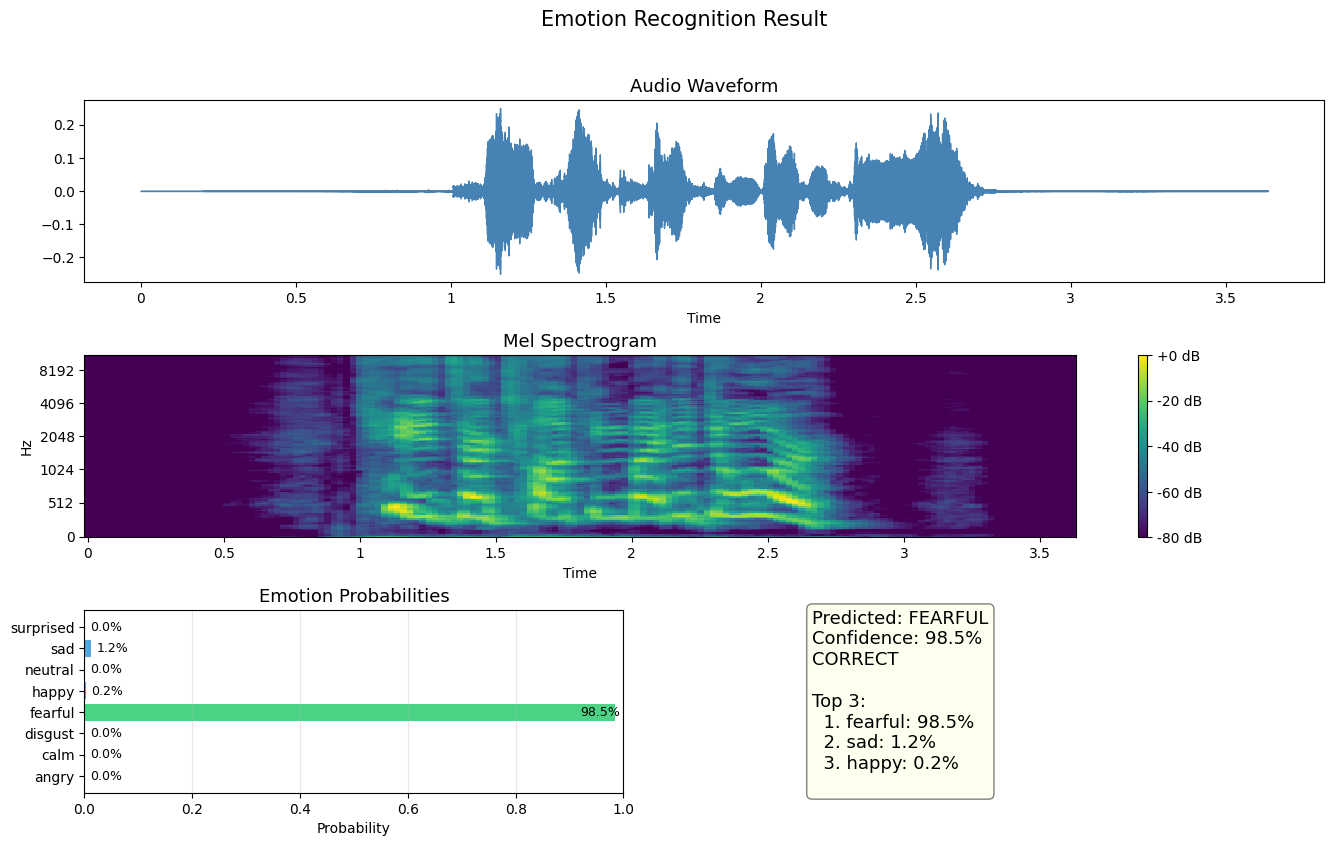

{'emotion': 'fearful',
 'confidence': 0.98502117395401,
 'top_predictions': [('fearful', 0.98502117395401),
  ('sad', 0.01235408429056406),
  ('happy', 0.0023919218219816685)],
 'all_probs': {'angry': 0.00011889522284036502,
  'calm': 6.406735792552354e-06,
  'disgust': 3.0626073566963896e-05,
  'fearful': 0.98502117395401,
  'happy': 0.0023919218219816685,
  'neutral': 2.6588075343170203e-05,
  'sad': 0.01235408429056406,
  'surprised': 5.0206424930365756e-05}}

In [53]:
df_test = pd.read_csv(PROCESSED_DIR / 'test_split.csv')

print("Testing one sample per emotion:\n")
results = []

for emotion in sorted(df_test['emotion'].unique()):
    sample = df_test[df_test['emotion'] == emotion].iloc[0]
    try:
        result  = recognizer.predict(sample['filepath'], top_k=3)
        correct = result['emotion'] == emotion
        results.append({'true': emotion, 'pred': result['emotion'],
                        'conf': result['confidence'], 'correct': correct})
        status = 'CORRECT' if correct else 'WRONG  '
        print(f"[{status}] True: {emotion:10s}  Pred: {result['emotion']:10s}  "
              f"Confidence: {result['confidence']:.1%}")
    except Exception as e:
        print(f"Error on {emotion}: {e}")

acc = sum(r['correct'] for r in results) / len(results) if results else 0
print(f"\nQuick test accuracy: {acc:.0%} ({sum(r['correct'] for r in results)}/{len(results)})")

# Visualize one random example
sample = df_test.sample(1).iloc[0]
print(f"\nVisualizing: {sample['emotion'].upper()}")
recognizer.visualize(
    sample['filepath'],
    true_emotion=sample['emotion'],
    save_path=str(RESULTS_DIR / 'example_prediction.png')
)
